In [94]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)


def extract_model(env: gym.Env):
	n_states = env.observation_space.n
	n_actions = env.action_space.n
	transition = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward = np.zeros((n_states, n_actions, n_states), dtype=float)

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob
				reward[state, action, next_state] = r

	expected_reward = np.sum(transition * reward, axis=2)
	return transition, reward, expected_reward


def q_values(transition, expected_reward, values, gamma):
	future = np.einsum("sat,t->sa", transition, values)
	return expected_reward + gamma * future


def policy_evaluation_matrix(transition, expected_reward, policy, gamma=0.99):
	n_states = transition.shape[0]
	rows = np.arange(n_states)
	policy_transition = transition[rows, policy]
	policy_reward = expected_reward[rows, policy]
	system = np.eye(n_states) - gamma * policy_transition
	values = np.linalg.solve(system, policy_reward)
	return values

In [95]:
def policy_iteration(transition, expected_reward, gamma=0.99, max_iterations=1000):
	n_states = transition.shape[0]
	policy = np.zeros(n_states, dtype=int)

	for iteration in range(max_iterations):
		values = policy_evaluation_matrix(transition, expected_reward, policy, gamma)
		q = q_values(transition, expected_reward, values, gamma)
		new_policy = np.argmax(q, axis=1)
		if np.array_equal(new_policy, policy):
			return values, policy, iteration + 1
		policy = new_policy

	values = policy_evaluation_matrix(transition, expected_reward, policy, gamma)
	return values, policy, max_iterations

def generate_episode(env, policy, epsilon=0.0, max_steps=200):
	state, _ = env.reset()
	episode = []

	for _ in range(max_steps):
		if np.random.rand() < epsilon:
			action = env.action_space.sample()
		else:
			action = policy[state]

		next_state, reward, terminated, truncated, _ = env.step(action)
		episode.append((state, action, reward))
		state = next_state

		if terminated or truncated:
			break

	return episode

In [96]:
def mc_control_epsilon(env, gamma=0.99, episodes=100000, start_epsilon=1.0, end_epsilon=0.1):

    nS = env.observation_space.n
    nA = env.action_space.n

    Q_sum = np.zeros((nS, nA))
    Q_cnt = np.zeros((nS, nA))
    policy = np.zeros(nS, dtype=int)

    rewards = []
    lengths = []

    epsilon = start_epsilon
    decay = (start_epsilon - end_epsilon) / episodes

    for i in range(episodes):

        state, _ = env.reset()

        if np.random.rand() < 0.2:
            state = env.observation_space.sample()
            env.unwrapped.s = state

        episode = []

        for _ in range(200):

            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = policy[state]

            next_state, reward, terminated, truncated, _ = env.step(action)

            episode.append((state, action, reward))
            state = next_state

            if terminated or truncated:
                break

        rewards.append(sum([r for _, _, r in episode]))
        lengths.append(len(episode))

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):

            s, a, r = episode[t]
            G = r + gamma * G

            if (s, a) not in visited:
                visited.add((s, a))
                Q_sum[s, a] += G
                Q_cnt[s, a] += 1
                policy[s] = np.argmax(Q_sum[s] / np.maximum(Q_cnt[s], 1e-8))

        epsilon = max(end_epsilon, epsilon - decay)

    Q = Q_sum / np.maximum(Q_cnt, 1e-8)

    return Q, policy, rewards, lengths

In [97]:
def off_policy_mc(env, gamma=0.99, episodes=50000, epsilon_start=1.0, epsilon_min=0.1):

    nS = env.observation_space.n
    nA = env.action_space.n

    Q = np.zeros((nS, nA))
    C = np.zeros((nS, nA))

    target_policy = np.zeros(nS, dtype=int)

    rewards = []
    lengths = []

    epsilon_decay = (epsilon_start - epsilon_min) / episodes
    epsilon = epsilon_start

    for _ in range(episodes):

        state, _ = env.reset()

        episode = []
        total_r = 0

        for _ in range(300):

            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = target_policy[state]

            next_state, reward, terminated, truncated, _ = env.step(action)

            episode.append((state, action, reward))
            total_r += reward
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_r)
        lengths.append(len(episode))

        G = 0
        W = 1

        for t in reversed(range(len(episode))):

            s, a, r = episode[t]
            G = r + gamma * G

            C[s, a] += W
            Q[s, a] += (W / C[s, a]) * (G - Q[s, a])

            target_policy[s] = np.argmax(Q[s])

            if a != target_policy[s]:
                break

            prob_behavior = (1 - epsilon) + (epsilon / nA)
            W *= 1.0 / prob_behavior

        epsilon = max(epsilon_min, epsilon - epsilon_decay)

    return Q, target_policy, rewards, lengths

In [98]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

In [99]:
def plot_metrics(rewards, lengths, title="Training"):
	plt.figure()
	plt.plot(rewards)
	plt.title(title + " - Rewards")
	plt.xlabel("Episode")
	plt.ylabel("Reward")
	plt.show()

	plt.figure()
	plt.plot(lengths)
	plt.title(title + " - Episode Length")
	plt.xlabel("Episode")
	plt.ylabel("Steps")
	plt.show()

FrozenLake 8x8 Experiment


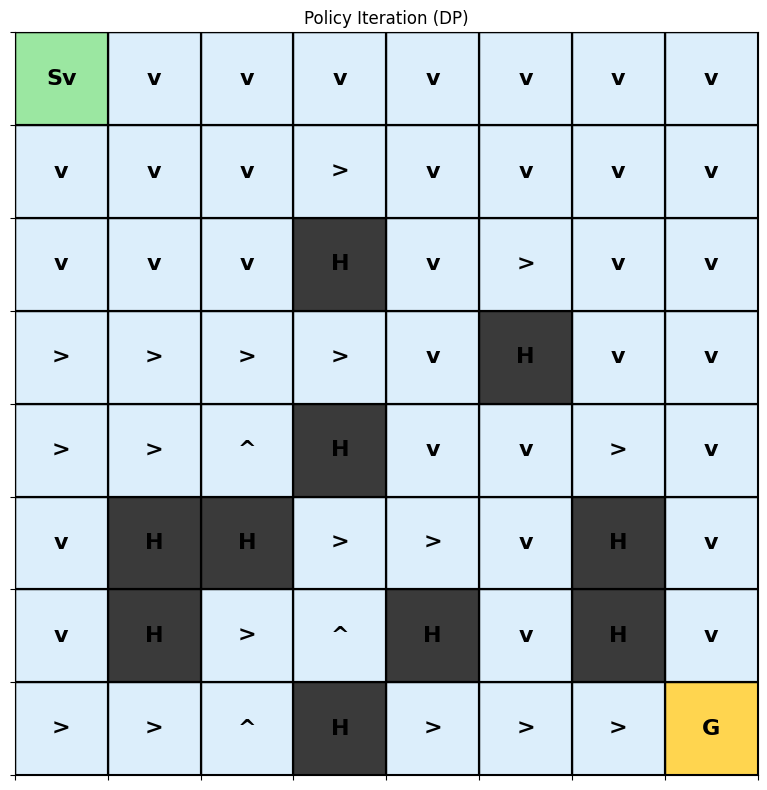

Running On-Policy MC...


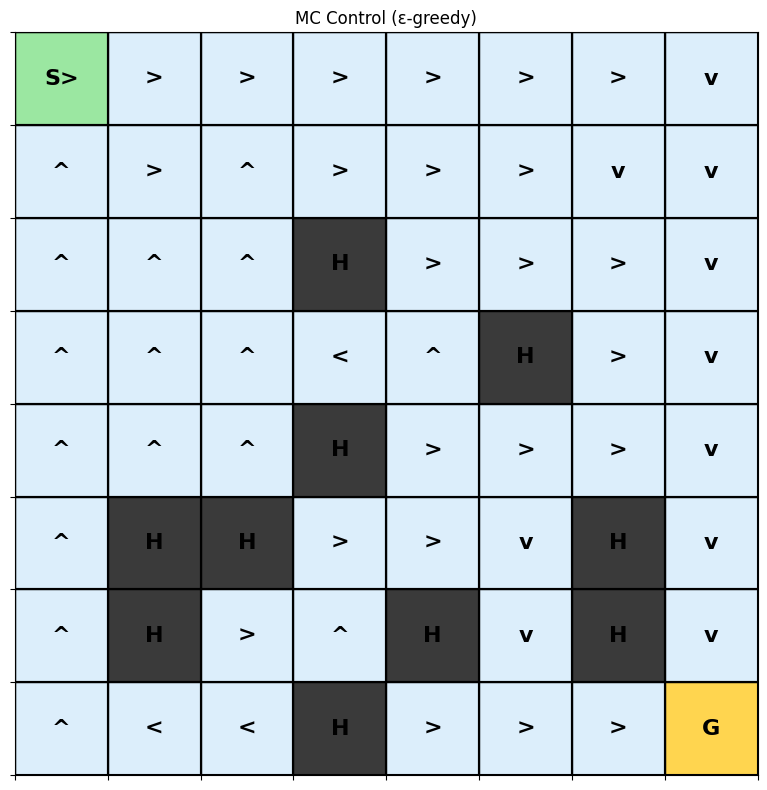

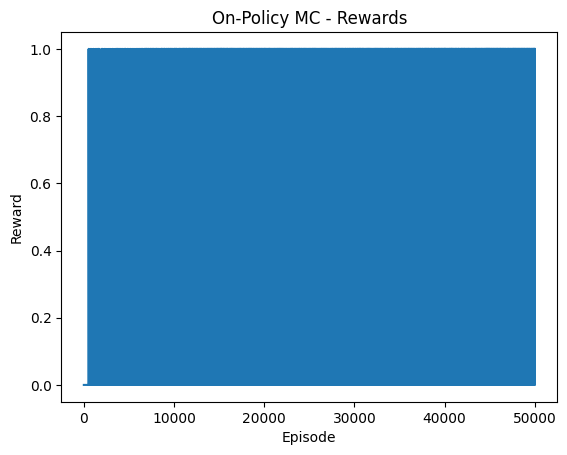

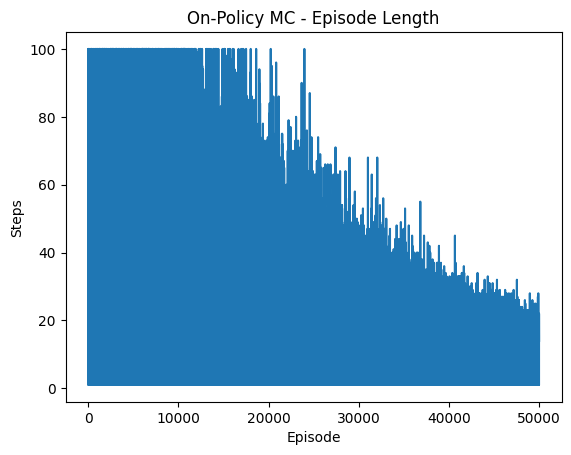

Running Off-Policy MC...


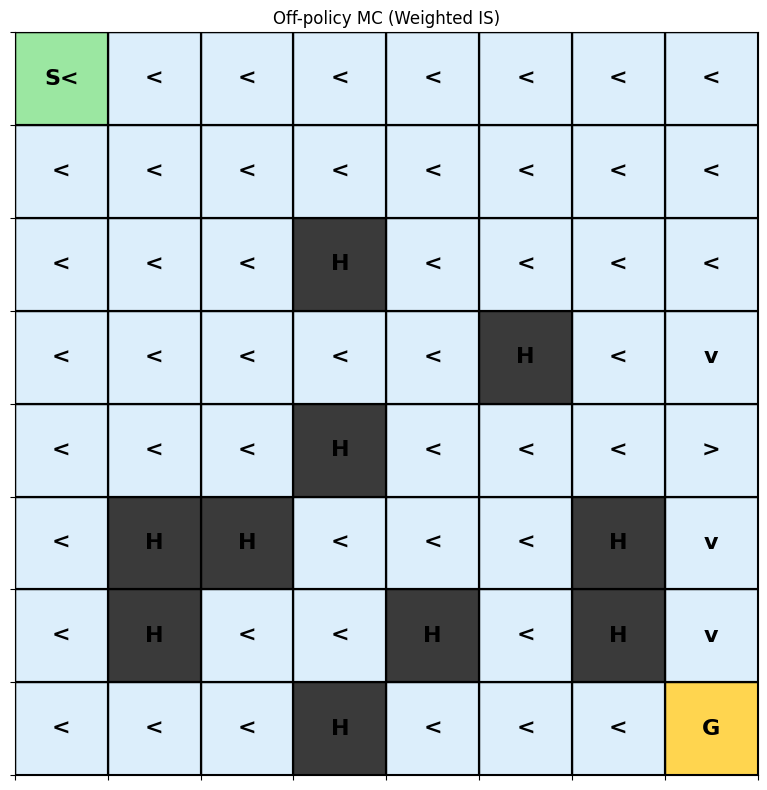

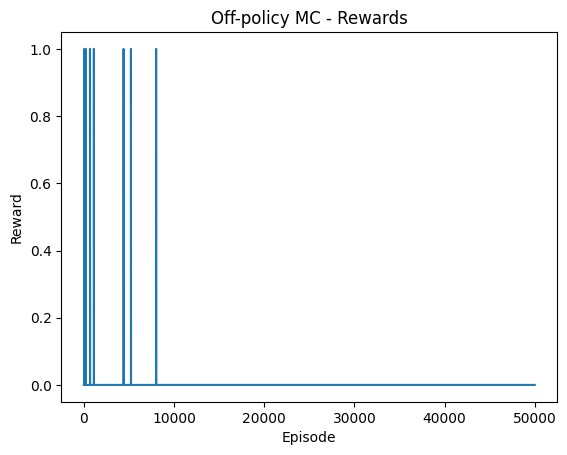

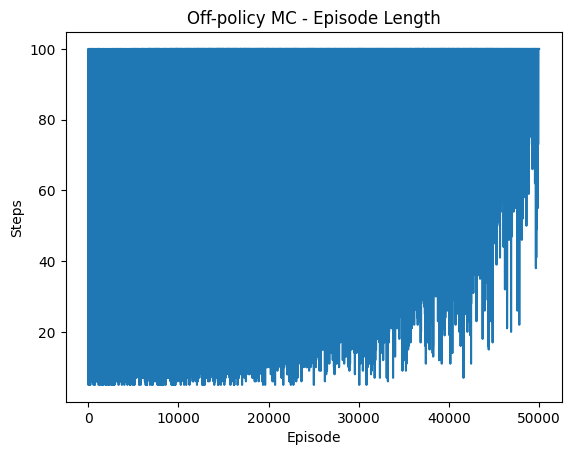

In [100]:
gamma = 0.99
env = build_env(slippery=False)

transition, reward, expected_reward = extract_model(env)

print("FrozenLake-v1 8x8")
print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
print("Legend: S=start, F=frozen, H=hole, G=goal")

V, pi_policy, _ = policy_iteration(transition, expected_reward, gamma=gamma)

print("\nPolicy Iteration Policy:")
print(pi_policy)

plot_policy_on_frozen_lake(
    env,
    pi_policy,
    title="Policy Iteration (DP)"
)

Q_mc, mc_policy = monte_carlo_control_greedy(
    env,
    gamma=gamma,
    episodes=8000
)

print("\nMonte Carlo Control Policy:")
print(mc_policy)

plot_policy_on_frozen_lake(
    env,
    mc_policy,
    title="Monte Carlo Control (Greedy)"
)

# Assignment 2



### (a) Policy Iteration (Model-Based)

**Interpretation:**
This policy is the optimal policy. It is found using full knowledge of the environment (transition and rewards). It gives a fixed best action for each state. It works well and reaches the goal safely. It converges fast because it does not need learning from experience.


### (b) Monte Carlo Control (ε-Greedy)

**Interpretation:**
This method learns from experience (episodes). It does not know the environment model. The ε-greedy method means the agent sometimes explores random actions and sometimes follows the best known action.

At the start, the policy is random and not good. After more episodes, it improves and becomes more stable.


### (c) Off-Policy Monte Carlo (Importance Sampling)

**Interpretation:**
This method learns a target policy using data collected from another behavior policy. Importance sampling is used to correct the difference between them.

The policy improves over time but can be unstable because of high variance in learning.


### (d) Reward vs Episode Plot

**Interpretation:**
At the start, rewards are low because the agent is exploring randomly. After some training, rewards increase as the agent learns better actions. Finally, rewards become stable when learning is complete.


### (e) Episode Length vs Episode Plot

**Interpretation:**
At the beginning, episodes are long because the agent moves randomly. Later, episode length becomes shorter because the agent learns better paths to the goal.


## 5. Effect of Discount Factor and Reward Schedule


### (a) Effect of Discount Factor (γ)

**γ = 0.5**
The agent only cares about immediate reward. It does not plan for the future well. This leads to bad or weak policies.

**γ = 0.99**
The agent cares about future rewards. It plans better and reaches the goal more consistently.

**Conclusion:**
Higher gamma gives better long-term planning.


### (b) Effect of Reward Schedule

**Sparse reward:**
Learning is slow because reward is only given at the goal.

**Dense reward:**
Learning is faster because the agent gets more feedback.

**Step penalty:**
The agent learns to take shorter paths.
